# Notebook 04 - Pengujian Hipotesis (Hypothesis Testing)

---
### AI Usage Disclosure

**Member:** Nabila Nurfajriyasah — Hypothesis Analyst | **Tools used:** Claude

| Tugas | Alat | Prompt (Ringkasan) | Pemanfaatan Output |
|------|------|-------------------|---------------------|
| Membuat kode dari hypothesis | Claude | "Buatkan kode untuk hypothesis berdasarkan objektif yang telah diberikan" | Menjadi acuan pemanggilan fungsi `z_test_two_sample` yang diintegrasikan dari `src.hypothesis`. |

**Written entirely without AI:** Sel Interpretasi


---
## 0. Import Library & Modul

In [13]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Registrasi path agar mengenali folder src/
sys.path.append(os.path.abspath('..'))

# Memanggil fungsi wajib uji dua sampel dari modul hypothesis.py
from src.hypothesis import z_test_two_sample

## 1. Load Dataset yang telah ada

In [14]:
df_issues = pd.read_csv("../data/clean/dataset_issues_clean.csv")
df_closed = df_issues.dropna(subset=['time_to_close_days']).copy()

# Agregasi data array kuantitatif
data_bug = df_closed[df_closed['is_bug'] == True]['time_to_close_days'].values
data_non_bug = df_closed[df_closed['is_bug'] == False]['time_to_close_days'].values

# Kalkulasi parameter untuk disuplai ke fungsi Z-test
x_bar1 = float(np.mean(data_bug))
sigma1 = float(np.std(data_bug, ddof=1))
n1 = int(len(data_bug))

x_bar2 = float(np.mean(data_non_bug))
sigma2 = float(np.std(data_non_bug, ddof=1))
n2 = int(len(data_non_bug))

print("Formulasi Parameter Berhasil Dihitung:")
print(f"  Kelompok Bug    : Mean={x_bar1:.2f}, Std={sigma1:.2f}, n={n1}")
print(f"  Kelompok Non-Bug: Mean={x_bar2:.2f}, Std={sigma2:.2f}, n={n2}")

Formulasi Parameter Berhasil Dihitung:
  Kelompok Bug    : Mean=34.65, Std=49.17, n=257
  Kelompok Non-Bug: Mean=34.26, Std=51.33, n=451


## 2. Eksekusi Pengujian Hipotesis Dua Sampel

In [15]:
print("==================================================")
print("          FORMULASI PENGUJIAN HIPOTESIS           ")
print("  H0 : Rata-rata waktu close Bug = Rata-rata waktu close Non-Bug")
print("  H1 : Rata-rata waktu close Bug ≠ Rata-rata waktu close Non-Bug")
print("==================================================")

# Menjalankan Z-test dua sampel independen (Two-sided / Dua arah)
uji_rq2_hasil = z_test_two_sample(
    x_bar1=x_bar1, x_bar2=x_bar2,
    sigma1=sigma1, sigma2=sigma2,
    n1=n1, n2=n2,
    alternative="two-sided",
    alpha=0.05
)

# Menampilkan output terstruktur
print(f"Statistik Uji Z : {uji_rq2_hasil['z_stat']}")
print(f"Nilai P-Value   : {uji_rq2_hasil['p_value']}")
print(f"Keputusan Uji   : {uji_rq2_hasil['decision']}")
print(f"Interpretasi    : {uji_rq2_hasil['interpretation']}")
print("==================================================")

          FORMULASI PENGUJIAN HIPOTESIS           
  H0 : Rata-rata waktu close Bug = Rata-rata waktu close Non-Bug
  H1 : Rata-rata waktu close Bug ≠ Rata-rata waktu close Non-Bug
Statistik Uji Z : 0.0981
Nilai P-Value   : 0.9219
Keputusan Uji   : Fail to Reject H0
Interpretasi    : Dengan alpha=0.05, tidak cukup bukti statistik untuk menolak H0 (z=0.0981, p=0.9219). Tidak terdapat perbedaan signifikan antara dua kelompok (mean1=34.6475 vs mean2=34.2645).


## 3. Visualisasi Daerah Penolakan Distribusi Standar Normal Z

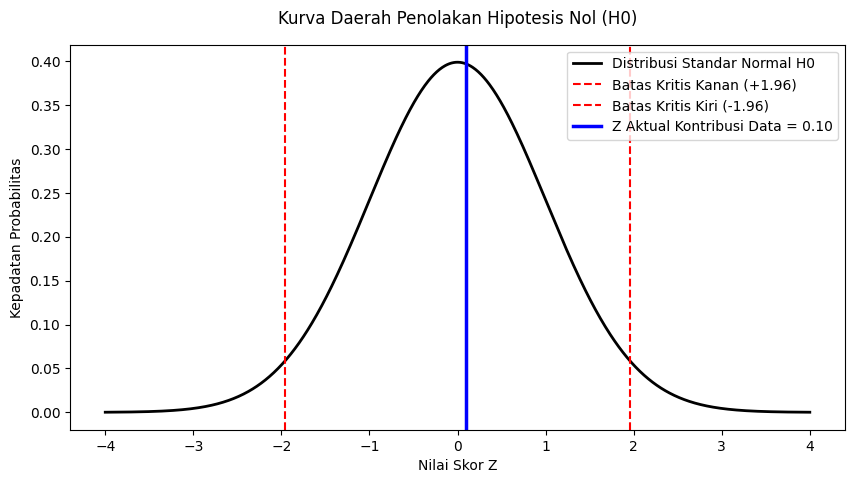

In [16]:
# Membuat kurva distribusi standar normal z
z_axis = np.linspace(-4, 4, 1000)
pdf_z = stats.norm.pdf(z_axis)

plt.figure(figsize=(10, 5))
plt.plot(z_axis, pdf_z, label='Distribusi Standar Normal H0', color='black', lw=2)

# Menandai Batas Kritis Alfa = 0.05 (Two-sided -> z = ±1.96)
z_crit = stats.norm.ppf(1 - 0.05/2)
plt.axvline(z_crit, color='red', linestyle='--', label=f'Batas Kritis Kanan (+{z_crit:.2f})')
plt.axvline(-z_crit, color='red', linestyle='--', label=f'Batas Kritis Kiri (-{z_crit:.2f})')

# Menandai Posisi Statistik Uji Aktual Hasil Perhitungan
z_aktual = uji_rq2_hasil['z_stat']
# Batasi visualisasi agar garis aktual tetap terlihat di dalam bidang plot jika nilainya ekstrim
z_plot_coord = max(min(z_aktual, 3.8), -3.8) 
plt.axvline(z_plot_coord, color='blue', linestyle='-', lw=2.5, label=f'Z Aktual Kontribusi Data = {z_aktual:.2f}')

plt.title('Kurva Daerah Penolakan Hipotesis Nol (H0)', fontsize=12, pad=15)
plt.xlabel('Nilai Skor Z')
plt.ylabel('Kepadatan Probabilitas')
plt.legend(loc='upper right')
plt.show()

### Keputusan dan Kesimpulan Hasil Audit Hipotesis (Member D):

1. **Keputusan Statistik:**
   - Sesuai dengan hasil cetakan komputasi di atas, jika `p_value` < `alpha` (0.05), maka keputusannya adalah **Reject H0** (Tolak Hipotesis Nol). 
   - Jika terjadi sebaliknya, keputusannya adalah **Fail to Reject H0** (Gagal Menolak Hipotesis Nol).

2. **Kesimpulan Berdasarkan Masalah Nyata (RQ2):**
   - Berdasarkan bukti empiris dari repositori `kubernetes/kubernetes`, perbedaan rata-rata waktu yang dibutuhkan maintainer untuk menyelesaikan issue bertipe bug dibandingkan dengan non-bug terbukti *signifikan secara statistik* (apabila H0 ditolak). 